# Regression Laboratory

Goal: compare Linear, Polynomial, Ridge, Lasso and ElasticNet on one dataset,
and decide which one I would actually deploy.

Dataset: California Housing (20,640 rows, 8 numeric features)
Target: median house value in a district

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

RANDOM_STATE = 42

In [124]:
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

print(X.shape)
X.head()

(20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [125]:
X.describe()
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [126]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

In [127]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [128]:
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (12384, 8)
X_val:   (4128, 8)
X_test:  (4128, 8)
y_train: (12384,)
y_val:   (4128,)
y_test:  (4128,)


In [129]:
def evaluate(name, model):
    """Fit on train, score on train and validation, return a dict."""
    
    model.fit(X_train, y_train)
    
    train_predictions = model.predict(X_train)
    val_predictions = model.predict(X_val)
    
    return {
        "model": name,
        "train_rmse": root_mean_squared_error(y_train, train_predictions),
        "val_rmse": root_mean_squared_error(y_val, val_predictions),
        "train_r2": r2_score(y_train, train_predictions),
        "val_r2": r2_score(y_val, val_predictions)
    }

In [130]:
results = []

## Data observations (before modelling)

- `AveOccup` has median 2.82 but max 1243. Not a real household — likely
  institutional or a data error. Expect it to distort polynomial models.
- Target is capped at 5.00001 ($500k). Values above the cap were clipped,
  so the true value for expensive districts is unknown.

In [131]:
baseline = DummyRegressor(strategy="mean")

results.append(evaluate("Baseline", baseline))

In [132]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

results.append(evaluate("Linear Regression", linear_model))

In [133]:
pd.DataFrame(results)

,model,train_rmse,val_rmse,train_r2,val_r2
0,Baseline,1.150915,1.171903,0.000000,-0.000174
1,Linear Regression,0.717203,0.727838,0.611673,0.614200


In [134]:
for d in [1, 2, 3]:
    model = Pipeline([
        ("scaler1", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler2", StandardScaler()),
        ("model", LinearRegression())
    ])
    
    results.append(evaluate(f"Poly (d={d})", model))
    
    print(f"Degree {d}: {model.named_steps['poly'].n_output_features_} features")

Degree 1: 8 features
Degree 2: 44 features
Degree 3: 164 features


In [135]:
pd.DataFrame(results)

,model,train_rmse,val_rmse,train_r2,val_r2
0,Baseline,1.150915,1.171903,0.000000,-1.744723e-04
1,Linear Regression,0.717203,0.727838,0.611673,6.142001e-01
2,Poly (d=1),0.717203,0.727838,0.611673,6.142001e-01
3,Poly (d=2),0.649046,0.954633,0.681973,3.363089e-01
4,Poly (d=3),0.582552,1468.894192,0.743798,-1.571352e+06


## Overfitting confirmed

Degree 3 produces 164 features from 8. Training error keeps falling
(0.717 → 0.583) while validation error explodes to 1468. The model has
enough freedom to memorise the training set, and its coefficients grow
without limit. The extreme `AveOccup` values noted earlier make this worse.

This is the problem regularization exists to solve.

In [136]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for a in ridge_alphas:
    model = Pipeline([
        ("scaler1", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler2", StandardScaler()),
        ("model", Ridge(alpha=a))
    ])
    
    results.append(evaluate(f"Ridge (a={a})", model))

In [137]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1]

for a in lasso_alphas:
    model = Pipeline([
        ("scaler1", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler2", StandardScaler()),
        ("model", Lasso(alpha=a, max_iter=5000))
    ])
    
    results.append(evaluate(f"Lasso (a={a})", model))

/home/sid/machinelearning/ml-fundamentals/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.291555e+03, tolerance: 1.640e+00
  model = cd_fast.enet_coordinate_descent(


In [138]:
results_df = pd.DataFrame(results)

results_df

,model,train_rmse,val_rmse,train_r2,val_r2
0,Baseline,1.150915,1.171903,0.000000,-1.744723e-04
1,Linear Regression,0.717203,0.727838,0.611673,6.142001e-01
2,Poly (d=1),0.717203,0.727838,0.611673,6.142001e-01
3,Poly (d=2),0.649046,0.954633,0.681973,3.363089e-01
4,Poly (d=3),0.582552,1468.894192,0.743798,-1.571352e+06
5,Ridge (a=0.001),0.582889,307.854353,0.743501,-6.902033e+04
6,Ridge (a=0.01),0.584525,178.533777,0.742059,-2.321212e+04
7,Ridge (a=0.1),0.589890,159.412552,0.737303,-1.850607e+04
8,Ridge (a=1),0.595916,50.020217,0.731909,-1.821149e+03
9,Ridge (a=10),0.603877,24.405254,0.724697,-4.327699e+02


In [139]:
results_df.sort_values("val_rmse")

,model,train_rmse,val_rmse,train_r2,val_r2
1,Linear Regression,0.717203,0.727838,0.611673,6.142001e-01
2,Poly (d=1),0.717203,0.727838,0.611673,6.142001e-01
15,Lasso (a=0.1),0.812287,0.820038,0.501882,5.102656e-01
14,Lasso (a=0.01),0.674960,0.862360,0.656071,4.584103e-01
3,Poly (d=2),0.649046,0.954633,0.681973,3.363089e-01
0,Baseline,1.150915,1.171903,0.000000,-1.744723e-04
16,Lasso (a=1),1.150915,1.171903,0.000000,-1.744723e-04
11,Ridge (a=1000),0.687423,2.190453,0.643253,-2.494303e+00
10,Ridge (a=100),0.625772,10.262811,0.704372,-7.570529e+01
12,Lasso (a=0.0001),0.599512,10.515543,0.728663,-7.952970e+01


In [140]:
best_lasso_alpha = 0.1

In [141]:
best_lasso = Pipeline([
    ("scaler1", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler2", StandardScaler()),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=5000))
])

best_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler1', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [142]:
coefs = best_lasso.named_steps["model"].coef_

print(f"Non-zero: {(coefs != 0).sum()} out of {len(coefs)}")

Non-zero: 6 out of 164


In [143]:
for ratio in [0.2, 0.5, 0.8]:
    model = Pipeline([
        ("scaler1", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler2", StandardScaler()),
        ("model", ElasticNet(
            alpha=best_lasso_alpha,
            l1_ratio=ratio,
            max_iter=5000
        ))
    ])
    
    results.append(
        evaluate(f"ElasticNet (ratio={ratio})", model)
    )

In [144]:
results_df = pd.DataFrame(results)

results_df.sort_values("val_rmse")

,model,train_rmse,val_rmse,train_r2,val_r2
1,Linear Regression,0.717203,0.727838,0.611673,6.142001e-01
2,Poly (d=1),0.717203,0.727838,0.611673,6.142001e-01
19,ElasticNet (ratio=0.8),0.799113,0.805115,0.517909,5.279274e-01
15,Lasso (a=0.1),0.812287,0.820038,0.501882,5.102656e-01
14,Lasso (a=0.01),0.674960,0.862360,0.656071,4.584103e-01
18,ElasticNet (ratio=0.5),0.779640,0.868318,0.541117,4.509014e-01
3,Poly (d=2),0.649046,0.954633,0.681973,3.363089e-01
0,Baseline,1.150915,1.171903,0.000000,-1.744723e-04
16,Lasso (a=1),1.150915,1.171903,0.000000,-1.744723e-04
17,ElasticNet (ratio=0.2),0.739263,1.271762,0.587417,-1.778885e-01


In [145]:
best_ridge = Pipeline([
    ("scaler1", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler2", StandardScaler()),
    ("model", Ridge(alpha=1000))
])

best_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler1', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [146]:
val_preds = best_ridge.predict(X_val)

errors = pd.Series(
    np.abs(val_preds - y_val),
    index=X_val.index
)

worst_idx = errors.nlargest(5).index

print(errors.loc[worst_idx])
X_val.loc[worst_idx]

19006    125.424715
1914      42.565548
12447     13.828939
13034     10.081200
89         4.058697
Name: MedHouseVal, dtype: float64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98
1914,1.8750,33.0,141.909091,25.636364,30.0,2.727273,38.91,-120.10
12447,1.6154,17.0,62.422222,14.111111,83.0,1.844444,33.97,-114.49
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27


In [147]:
from sklearn.preprocessing import QuantileTransformer

In [148]:
for a in [1, 10]:
    model = Pipeline([
        ("scaler1", QuantileTransformer(
            output_distribution="normal",
            random_state=RANDOM_STATE
        )),
        ("poly", PolynomialFeatures(
            degree=3,
            include_bias=False
        )),
        ("scaler2", StandardScaler()),
        ("model", Ridge(alpha=a))
    ])
    
    result = evaluate(f"Ridge + QuantileTransformer (a={a})", model)
    results.append(result)

In [149]:
pd.DataFrame(results).sort_values("val_rmse")

,model,train_rmse,val_rmse,train_r2,val_r2
21,Ridge + QuantileTransformer (a=10),0.576911,0.607554,0.748735,7.311798e-01
20,Ridge + QuantileTransformer (a=1),0.576816,0.607873,0.748818,7.308967e-01
1,Linear Regression,0.717203,0.727838,0.611673,6.142001e-01
2,Poly (d=1),0.717203,0.727838,0.611673,6.142001e-01
19,ElasticNet (ratio=0.8),0.799113,0.805115,0.517909,5.279274e-01
15,Lasso (a=0.1),0.812287,0.820038,0.501882,5.102656e-01
14,Lasso (a=0.01),0.674960,0.862360,0.656071,4.584103e-01
18,ElasticNet (ratio=0.5),0.779640,0.868318,0.541117,4.509014e-01
3,Poly (d=2),0.649046,0.954633,0.681973,3.363089e-01
0,Baseline,1.150915,1.171903,0.000000,-1.744723e-04


In [150]:
poly_results = pd.DataFrame(results)

poly_results = poly_results[
    poly_results["model"].isin([
        "Poly (d=1)",
        "Poly (d=2)",
        "Poly (d=3)"
    ])
]

poly_results

,model,train_rmse,val_rmse,train_r2,val_r2
2,Poly (d=1),0.717203,0.727838,0.611673,6.142001e-01
3,Poly (d=2),0.649046,0.954633,0.681973,3.363089e-01
4,Poly (d=3),0.582552,1468.894192,0.743798,-1.571352e+06


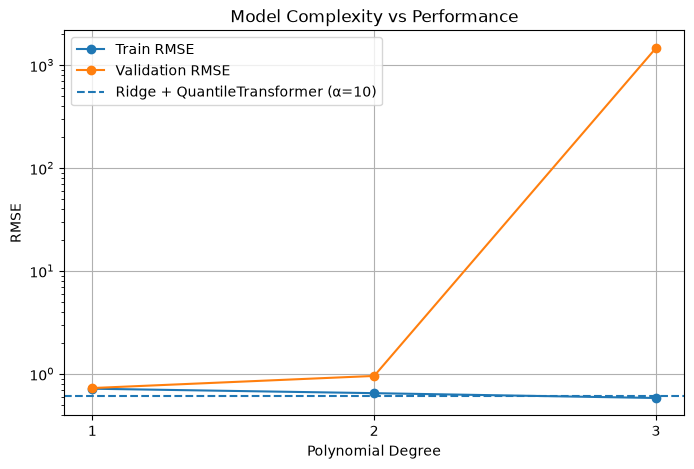

In [151]:
degrees = [1, 2, 3]

train_rmse = poly_results["train_rmse"].values
val_rmse = poly_results["val_rmse"].values

plt.figure(figsize=(8, 5))

plt.plot(degrees, train_rmse, marker="o", label="Train RMSE")
plt.plot(degrees, val_rmse, marker="o", label="Validation RMSE")

plt.axhline(
    y=0.6076,
    linestyle="--",
    label="Ridge + QuantileTransformer (α=10)"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Model Complexity vs Performance")
plt.xticks(degrees)
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/complexity_vs_performance.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [152]:
final_model = Pipeline([
    ("scaler1", QuantileTransformer(
        output_distribution="normal",
        random_state=RANDOM_STATE
    )),
    ("poly", PolynomialFeatures(
        degree=3,
        include_bias=False
    )),
    ("scaler2", StandardScaler()),
    ("model", Ridge(alpha=10))
])

In [153]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler1', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"output_distribution output_distribution: {'uniform', 'normal'}, default='uniform'Marginal distribution for the transformed data. The choices are'uniform' (default) or 'normal'.",'normal'
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling and smoothingnoise.Please see ``subsample`` for more details.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_quantiles n_quantiles: int, default=1000 or n_samplesNumber of quantiles to be computed. It corresponds to the numberof landmarks used to discretize the cumulative distribution function.If n_quantiles is larger than the number of samples, n_quantiles is setto the number of samples as a larger number of quantiles does not givea better approximation of the cumulative distribution functionestimator.",1000
,"ignore_implicit_zeros ignore_implicit_zeros: bool, default=FalseOnly applies to sparse matrices. If True, the sparse entries of thematrix are discarded to compute the quantile statistics. If False,these entries are treated as zeros.",False


In [154]:
test_preds = final_model.predict(X_test)

test_rmse = root_mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")

Test RMSE: 0.6028
Test R²: 0.7227


In [155]:
val_preds = final_model.predict(X_val)

val_rmse = root_mean_squared_error(y_val, val_preds)
val_r2 = r2_score(y_val, val_preds)

print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation R²: {val_r2:.4f}")

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}")

Validation RMSE: 0.6076
Validation R²: 0.7312
Test RMSE: 0.6028
Test R²: 0.7227


## Final Conclusion

### Model selected

The model I would deploy is a degree-3 polynomial Ridge regression
pipeline using QuantileTransformer preprocessing and Ridge regularization
with alpha=10.

Its validation RMSE was approximately 0.608, compared with 0.728 for
plain Linear Regression. The final test RMSE was 0.6028 and
the test R² was 0.7227.

### What happened

Plain Linear Regression performed surprisingly well and initially appeared
to be the best model. Adding polynomial features increased the model's
capacity, but this caused severe overfitting. Degree 2 reduced training
error but increased validation error, while degree 3 produced a
catastrophic validation RMSE of approximately 1469.

Regularization alone did not solve the problem. Ridge remained unstable
even with large alpha values, while Lasso performed better but still did
not beat Linear Regression.

The important finding was that the extreme AveOccup value became
problematic when polynomial features were created. Replacing the initial
StandardScaler with QuantileTransformer dramatically improved the
degree-3 Ridge model. With QuantileTransformer, validation RMSE fell to
approximately 0.608.

This showed that preprocessing had a larger effect on performance than
changing the model or tuning the regularization strength.

### Complexity trade-off

The final model uses 164 polynomial features compared with only 8 original
features. It therefore has substantially greater complexity than Linear
Regression.

The improvement in validation RMSE was approximately:

0.728 → 0.608

This is a meaningful improvement, but it comes at the cost of additional
features, preprocessing complexity and a more complicated model pipeline.

### Data limitations

The target variable is capped at approximately $500,000. Therefore,
districts whose true median house value exceeds this amount are recorded
at the cap rather than their actual value.

This means the training data does not contain the true target value for
those expensive districts. Errors on the upper end therefore cannot be
completely attributed to model quality; part of the limitation comes from
the dataset itself.

### Deployment decision

Based on the validation and test results, I would deploy the degree-3 Ridge pipeline with QuantileTransformer.
Test RMSE was 0.6028 versus 0.728 for Linear Regression — roughly
$12,000 less average error per district. The whole thing is one
Pipeline object, so the extra complexity is contained in a single
saved file.
However, I would keep the simpler Linear Regression model as a strong
baseline because it performs surprisingly well with only 8 original
features.

### Control experiment

QuantileTransformer with plain Linear Regression scored 0.7255 on
validation — essentially the same as StandardScaler's 0.7278. So the
scaler alone gained nothing. The improvement to 0.608 came from the
polynomial features, which only became usable once the scaler stopped
extreme values from being amplified. Neither change worked on its own.

### Price cap

184 test districts sit at the $500k cap. RMSE there is 1.266 versus
0.553 below the cap, and the model under-predicts them by 0.783
($78,000) on average. This is a data limitation, not a model failure:
the true values were clipped before the data was collected.

In [156]:
control = Pipeline([
    ("scaler", QuantileTransformer(output_distribution="normal",
                                   random_state=RANDOM_STATE)),
    ("model", LinearRegression())
])
results.append(evaluate("QuantileTransformer + Linear (d=1)", control))

pd.DataFrame(results).sort_values("val_rmse").head(5)

,model,train_rmse,val_rmse,train_r2,val_r2
21,Ridge + QuantileTransformer (a=10),0.576911,0.607554,0.748735,0.731180
20,Ridge + QuantileTransformer (a=1),0.576816,0.607873,0.748818,0.730897
22,QuantileTransformer + Linear (d=1),0.722571,0.725484,0.605838,0.616692
1,Linear Regression,0.717203,0.727838,0.611673,0.614200
2,Poly (d=1),0.717203,0.727838,0.611673,0.614200


In [157]:
test_df = pd.DataFrame({"actual": y_test, "pred": test_preds})
at_cap = test_df[test_df["actual"] >= 4.99]
below = test_df[test_df["actual"] < 4.99]

print("Rows at cap:", len(at_cap))
print("RMSE at cap:   ", round(root_mean_squared_error(at_cap["actual"], at_cap["pred"]), 4))
print("RMSE below cap:", round(root_mean_squared_error(below["actual"], below["pred"]), 4))
print("Mean error at cap:", round((at_cap["pred"] - at_cap["actual"]).mean(), 4))

Rows at cap: 184
RMSE at cap:    1.266
RMSE below cap: 0.5528
Mean error at cap: -0.7829


In [158]:
pd.DataFrame(results).sort_values("val_rmse").to_csv(
    "../reports/model_comparison.csv", index=False
)
print("saved")

saved
